In [26]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.cluster import KMeans
import numpy as np
import os
import shutil

# Path to your mixed image folder
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed"

# Load MobileNetV2 model once
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

# Define feature extraction function
def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)
    features = model.predict(x)
    return features[0]

# Process images
features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(image_folder, fname)
        feat = extract_features(path)
        features.append(feat)
        filenames.append(fname)

#features = np.array(features)
features = np.array(features, dtype=np.float64)  # <- FIXED LINE

# Cluster features
k = 5  # You can adjust this
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(features)

# Organize images into cluster folders
for i in range(k):
    os.makedirs(f"grouped_images_v4/cluster_{i}", exist_ok=True)

for fname, cluster_id in zip(filenames, clusters):
    src = os.path.join(image_folder, fname)
    dst = os.path.join(f"grouped_images_v4/cluster_{cluster_id}", fname)
    shutil.copy(src, dst)

print("Image grouping complete.")


1/1 [==============================] - 0s 19ms/step
Image grouping complete.


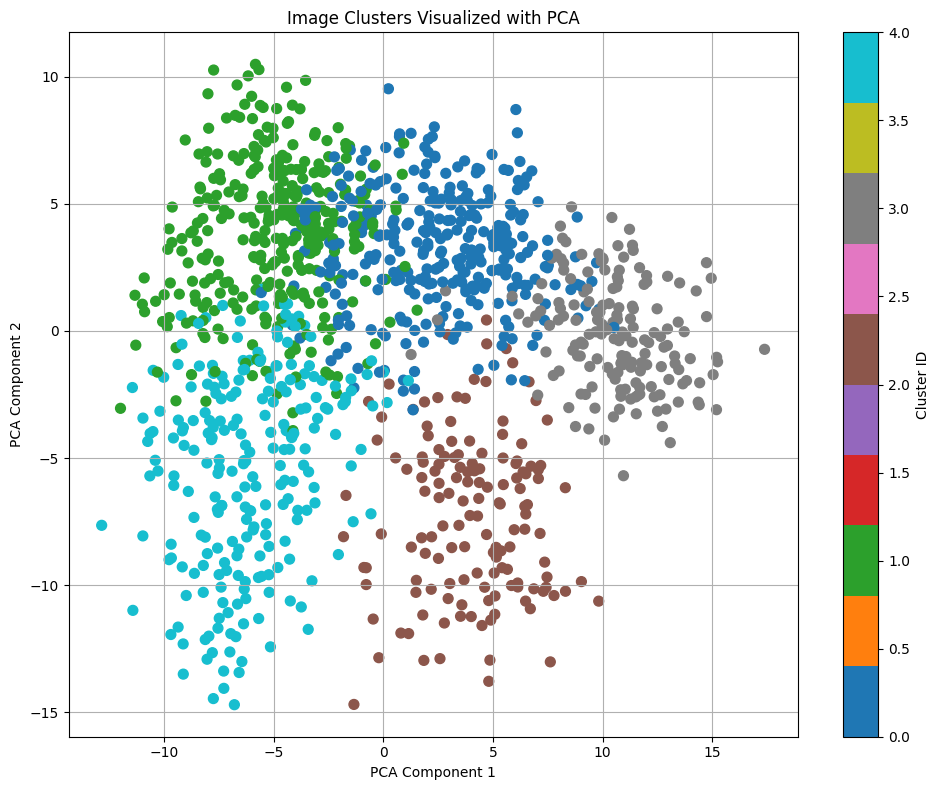

In [27]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE  # Optional alternative to PCA

# Reduce features to 2D using PCA
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# Plot clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=clusters, cmap='tab10', s=50)

# Annotate with filenames if needed (optional)
# for i, fname in enumerate(filenames):
#     plt.annotate(fname, (reduced_features[i, 0], reduced_features[i, 1]), fontsize=6)

plt.title("Image Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.cluster import KMeans
import numpy as np
import os
import shutil

# === 1. Load your .h5 model ===
full_model = load_model("299-model-test-v5.h5")

# === 2. Remove the last layer (softmax) to get features ===
# Assumes second-last layer is feature layer
feature_model = Model(inputs=full_model.input, outputs=full_model.layers[-2].output)

# === 3. Feature extraction function using your model ===
def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(x)  # If you used MobileNetV2 as base
    x = np.expand_dims(x, axis=0)
    features = feature_model.predict(x)
    return features[0]

# === 4. Directory paths ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed"
output_folder = "grouped_images_custom_model_v3"
os.makedirs(output_folder, exist_ok=True)

# === 5. Extract features from all images ===
features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(image_folder, fname)
        try:
            feat = extract_features(path)
            features.append(feat)
            filenames.append(fname)
        except Exception as e:
            print(f"Error processing {fname}: {e}")

#features = np.array(features)
features = np.array(features, dtype=np.float64)  # <- FIXED LINE


# === 6. Cluster features ===
k = 5  # or 5, if you know number of diseases
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(features)

# === 7. Organize images into folders ===
for i in range(k):
    os.makedirs(os.path.join(output_folder, f"cluster_{i}"), exist_ok=True)

for fname, cluster_id in zip(filenames, clusters):
    src = os.path.join(image_folder, fname)
    dst = os.path.join(output_folder, f"cluster_{cluster_id}", fname)
    shutil.copy(src, dst)

print("Image grouping complete using custom model.")


1/1 [==============================] - 0s 20ms/step
Image grouping complete using custom model.


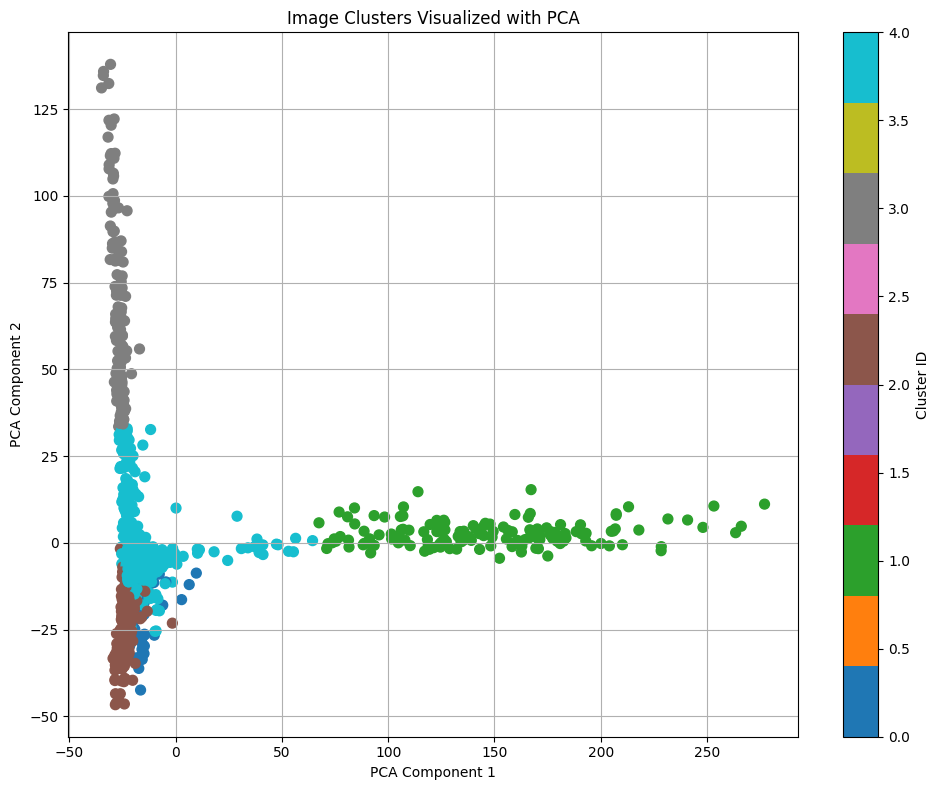

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE  # Optional alternative to PCA

# Reduce features to 2D using PCA
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# Plot clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=clusters, cmap='tab10', s=50)

# Annotate with filenames if needed (optional)
# for i, fname in enumerate(filenames):
#     plt.annotate(fname, (reduced_features[i, 0], reduced_features[i, 1]), fontsize=6)

plt.title("Image Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.tight_layout()
plt.show()


## Continual clustering

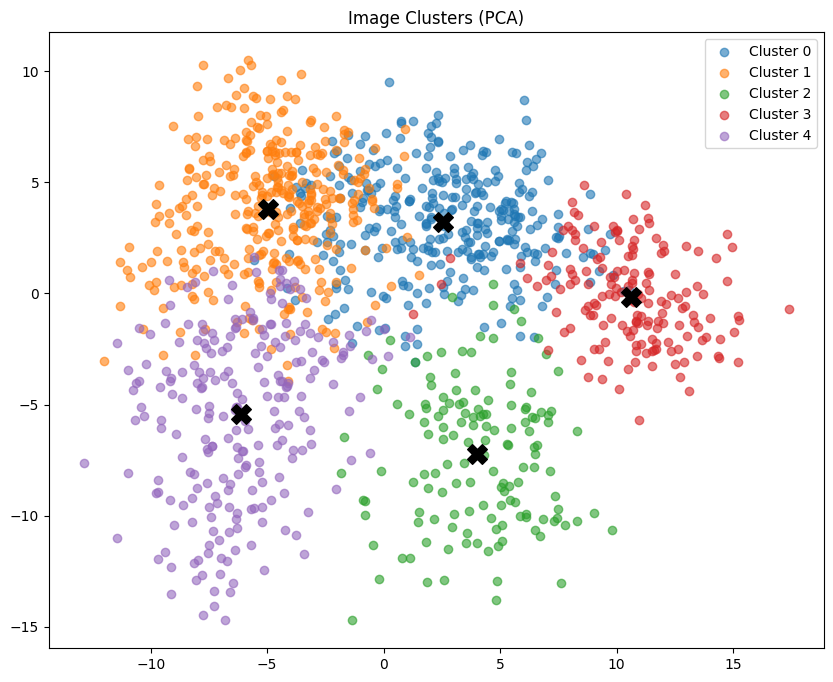

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# Store cluster centers in 2D
reduced_centers = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(10, 8))
for i in range(k):
    cluster_points = reduced_features[clusters == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {i}", alpha=0.6)
    plt.scatter(reduced_centers[i][0], reduced_centers[i][1], marker='X', s=200, c='black')  # centroids

plt.title("Image Clusters (PCA)")
plt.legend()
plt.savefig("cluster_graph.png")
plt.show()




In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np

def predict_cluster_and_plot(new_img_path, threshold=20.0):
    # Step 1: Extract and convert features
    new_feat = extract_features(new_img_path).astype(np.float64)

    # Step 2: Predict cluster
    cluster_id = kmeans.predict(np.array([new_feat], dtype=np.float64))[0]

    # Step 3: Compute distance from cluster center
    dist = np.linalg.norm(new_feat - kmeans.cluster_centers_[cluster_id])

    # Step 4: Reduce to 2D using PCA
    reduced_new = pca.transform(np.array([new_feat], dtype=np.float64))[0]

    # Step 5: Plot clusters
    plt.clf()  # 🔄 Clear the current figure
    plt.figure(figsize=(10, 8))
    for i in range(k):
        cluster_points = reduced_features[clusters == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {i}", alpha=0.6)
        plt.scatter(reduced_centers[i][0], reduced_centers[i][1], marker='X', s=200, c='black')

    # Step 6: Plot new image point
    plt.scatter(reduced_new[0], reduced_new[1], c='red', s=150, label='New Image', edgecolors='black')

    plt.title(f"Prediction for: {os.path.basename(new_img_path)}")
    plt.legend()
    plt.pause(0.1)  # 🔄 Brief pause for UI to update (useful in notebooks or live scripts)
    plt.show(block=False)

    # Step 7: Anomaly detection
    if dist > threshold:
        print(f"⚠️ Possible Anomaly Detected! Distance from cluster center: {dist:.2f}")
        return cluster_id, dist, True  # anomaly=True
    else:
        print(f"✅ Assigned to Cluster {cluster_id} (Distance: {dist:.2f})")
        return cluster_id, dist, False  # anomaly=False


def evaluate_images_in_folder(folder_path, threshold=20.0):
    anomaly_count = 0
    total_images = 0

    for fname in os.listdir(folder_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(folder_path, fname)
            total_images += 1
            print(f"\n📸 Evaluating: {fname}")
            try:
                cluster_id, distance, is_anomaly = predict_cluster_and_plot(img_path, threshold)
                if is_anomaly:
                    anomaly_count += 1
            except Exception as e:
                print(f"❌ Error processing {fname}: {e}")

    print("\n🎯 Evaluation Summary:")
    print(f"🔍 Total Images Evaluated: {total_images}")
    print(f"⚠️ Total Anomalies Detected: {anomaly_count}")

# Call this
new_images_folder = r"D:\CSE299\batch-1"
evaluate_images_in_folder(new_images_folder)



## HDSCAN

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
import hdbscan
from hdbscan import prediction

# === Load MobileNetV2 for feature extraction ===
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)
    features = model.predict(x)
    return features[0]

# === Step 1: Feature extraction for dataset ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(image_folder, fname)
        feat = extract_features(path)
        features.append(feat)
        filenames.append(fname)

features = np.array(features, dtype=np.float64)

# === Step 2: HDBSCAN clustering ===
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, prediction_data=True)  # Enable prediction
clusterer.fit(features)

# === Step 3: PCA for visualization ===
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# === Step 4: Store cluster labels ===
labels = clusterer.labels_
unique_clusters = set(labels)

# === Step 5: Organize images by cluster ===
output_folder = "grouped_images_hdbscan_v2"
os.makedirs(output_folder, exist_ok=True)

for cluster_id in unique_clusters:
    folder_name = "noise" if cluster_id == -1 else f"cluster_{cluster_id}"
    os.makedirs(os.path.join(output_folder, folder_name), exist_ok=True)

for fname, cluster_id in zip(filenames, labels):
    folder_name = "noise" if cluster_id == -1 else f"cluster_{cluster_id}"
    src = os.path.join(image_folder, fname)
    dst = os.path.join(output_folder, folder_name, fname)
    shutil.copy(src, dst)




1/1 [==============================] - 0s 19ms/step


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


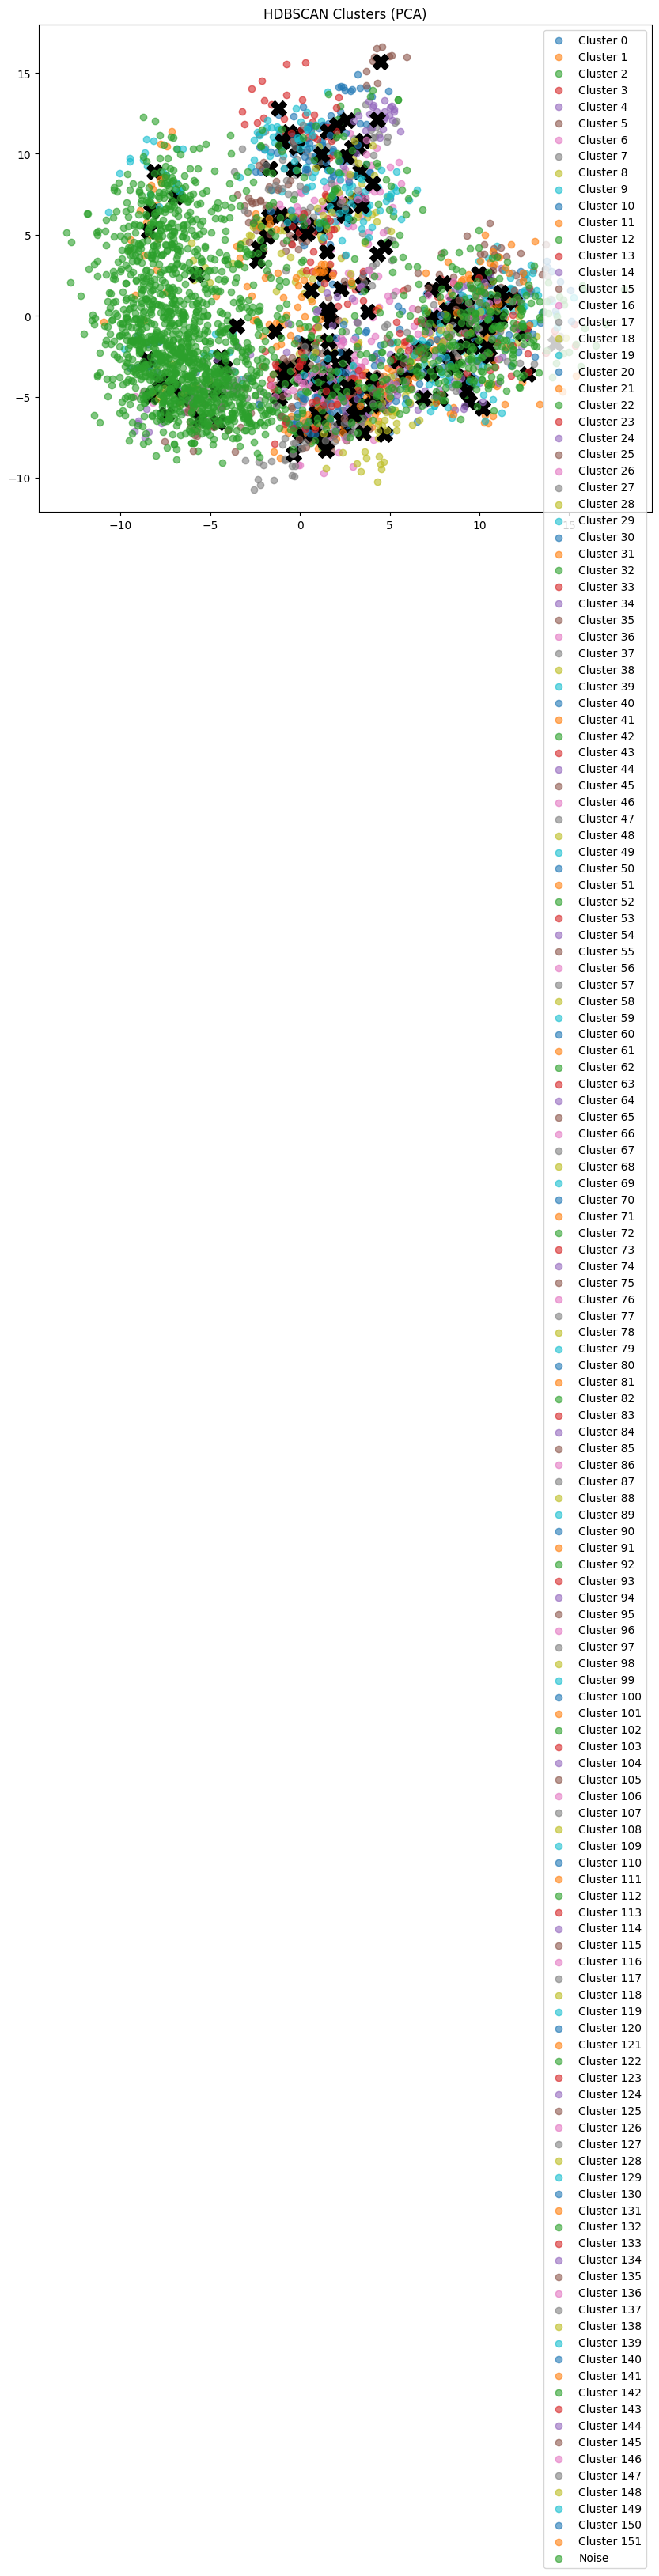

In [2]:
# === Step 6: Plot cluster map ===
reduced_centers = {}  # Optional pseudo-centers
for i in unique_clusters:
    cluster_points = reduced_features[labels == i]
    if len(cluster_points) > 0:
        reduced_centers[i] = np.mean(cluster_points, axis=0)

plt.figure(figsize=(10, 8))
for cluster_id in unique_clusters:
    cluster_points = reduced_features[labels == cluster_id]
    label_name = "Noise" if cluster_id == -1 else f"Cluster {cluster_id}"
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=label_name, alpha=0.6)
    if cluster_id in reduced_centers:
        plt.scatter(*reduced_centers[cluster_id], marker='X', s=200, c='black')

plt.legend()
plt.title("HDBSCAN Clusters (PCA)")
plt.savefig("hdbscan_cluster_graph.png")
plt.show()

In [ ]:

# === Step 7: Predict new image using approximate_predict ===
def predict_cluster_and_plot_hdbscan(new_img_path):
    new_feat = extract_features(new_img_path).astype(np.float64)
    reduced_new = pca.transform([new_feat])[0]

    # Predict cluster label and probability
    pred_label, confidence = prediction.approximate_predict(clusterer, [new_feat])
    pred_label = pred_label[0]
    confidence = confidence[0]

    # Plot with existing
    plt.clf()
    plt.figure(figsize=(10, 8))
    for cluster_id in unique_clusters:
        cluster_points = reduced_features[labels == cluster_id]
        label_name = "Noise" if cluster_id == -1 else f"Cluster {cluster_id}"
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=label_name, alpha=0.6)

    plt.scatter(reduced_new[0], reduced_new[1], c='red', s=150, label='New Image', edgecolors='black')
    plt.title(f"Prediction: {os.path.basename(new_img_path)} - Cluster {pred_label} (Confidence: {confidence:.2f})")
    plt.legend()
    plt.pause(0.1)
    plt.show(block=False)

    if pred_label == -1 or confidence < 0.3:
        print(f"⚠️ Likely Anomaly Detected! Label: {pred_label}, Confidence: {confidence:.2f}")
        return pred_label, confidence, True
    else:
        print(f"✅ Assigned to Cluster {pred_label} (Confidence: {confidence:.2f})")
        return pred_label, confidence, False

# === Step 8: Evaluate new images in folder ===
def evaluate_images_in_folder_hdbscan(folder_path):
    anomaly_count = 0
    total_images = 0

    for fname in os.listdir(folder_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(folder_path, fname)
            total_images += 1
            print(f"\n📸 Evaluating: {fname}")
            try:
                _, _, is_anomaly = predict_cluster_and_plot_hdbscan(img_path)
                if is_anomaly:
                    anomaly_count += 1
            except Exception as e:
                print(f"❌ Error processing {fname}: {e}")

    print("\n🎯 Evaluation Summary:")
    print(f"🔍 Total Images Evaluated: {total_images}")
    print(f"⚠️ Total Anomalies Detected: {anomaly_count}")

# === Final Call ===
new_images_folder = r"D:\CSE299\batch-1"
evaluate_images_in_folder_hdbscan(new_images_folder)